# Data Preprocessing

## Importing the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [2]:
df=pd.read_csv("D:/ML Internship/NASA-NEO-Predictor/Data/neo.csv")
df

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True
...,...,...,...,...,...,...,...,...,...,...
90831,3763337,(2016 VX1),0.026580,0.059435,52078.886692,1.230039e+07,Earth,False,25.00,False
90832,3837603,(2019 AD3),0.016771,0.037501,46114.605073,5.432121e+07,Earth,False,26.00,False
90833,54017201,(2020 JP3),0.031956,0.071456,7566.807732,2.840077e+07,Earth,False,24.60,False
90834,54115824,(2021 CN5),0.007321,0.016370,69199.154484,6.869206e+07,Earth,False,27.80,False


## Exploring the dataset

In [3]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [4]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 90836
Columns: 10


In [5]:
df.columns

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  str    
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  str    
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), str(2)
memory usage: 5.7 MB


In [7]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


## Checking the Missing values

In [8]:
df.isnull().sum()

id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

## Checking the Duplicate rows

In [9]:
df.duplicated().sum()

np.int64(0)

## Checking Target distribution

In [10]:
df["hazardous"].value_counts()

hazardous
False    81996
True      8840
Name: count, dtype: int64

## Plot Target distribution

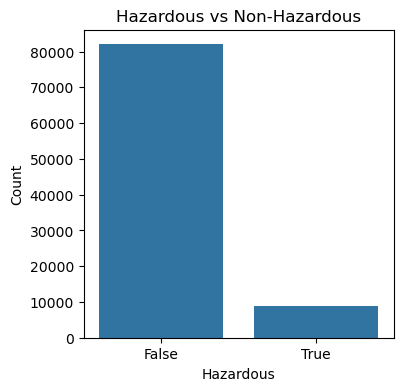

In [11]:
plt.figure(figsize=(4,4))
sns.countplot(x=df["hazardous"])
plt.title("Hazardous vs Non-Hazardous")
plt.xlabel("Hazardous")
plt.ylabel("Count")
plt.show()

## Removing Unncessary columns

In [12]:
columns_to_drop = ["id","name","neo_reference_id","orbiting_body"]
df.drop(columns=columns_to_drop, errors="ignore",inplace=True)
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,sentry_object,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,False,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,False,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,False,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,False,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,False,20.09,True
...,...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,False,25.00,False
90832,0.016771,0.037501,46114.605073,5.432121e+07,False,26.00,False
90833,0.031956,0.071456,7566.807732,2.840077e+07,False,24.60,False
90834,0.007321,0.016370,69199.154484,6.869206e+07,False,27.80,False


## Encoding Categorical columns

In [13]:
df.select_dtypes(include="object").columns

Index([], dtype='str')

## Converting Boolean columns to Binary columns

In [14]:
bool_cols=df.select_dtypes(include="bool").columns
for col in bool_cols:
    df[col] = df[col].astype(int)
df

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,sentry_object,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,0,16.73,0
1,0.265800,0.594347,73588.726663,6.143813e+07,0,20.00,1
2,0.722030,1.614507,114258.692129,4.979872e+07,0,17.83,0
3,0.096506,0.215794,24764.303138,2.543497e+07,0,22.20,0
4,0.255009,0.570217,42737.733765,4.627557e+07,0,20.09,1
...,...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,0,25.00,0
90832,0.016771,0.037501,46114.605073,5.432121e+07,0,26.00,0
90833,0.031956,0.071456,7566.807732,2.840077e+07,0,24.60,0
90834,0.007321,0.016370,69199.154484,6.869206e+07,0,27.80,0


## Separating the Independent features and Target Features

In [15]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [16]:
X

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,sentry_object,absolute_magnitude
0,1.198271,2.679415,13569.249224,5.483974e+07,0,16.73
1,0.265800,0.594347,73588.726663,6.143813e+07,0,20.00
2,0.722030,1.614507,114258.692129,4.979872e+07,0,17.83
3,0.096506,0.215794,24764.303138,2.543497e+07,0,22.20
4,0.255009,0.570217,42737.733765,4.627557e+07,0,20.09
...,...,...,...,...,...,...
90831,0.026580,0.059435,52078.886692,1.230039e+07,0,25.00
90832,0.016771,0.037501,46114.605073,5.432121e+07,0,26.00
90833,0.031956,0.071456,7566.807732,2.840077e+07,0,24.60
90834,0.007321,0.016370,69199.154484,6.869206e+07,0,27.80


In [17]:
y

0        0
1        1
2        0
3        0
4        1
        ..
90831    0
90832    0
90833    0
90834    0
90835    0
Name: hazardous, Length: 90836, dtype: int64

## Splitting the dataset into Training set and Test set

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=37,stratify=y)

In [19]:
X_train

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,sentry_object,absolute_magnitude
77212,0.036021,0.080545,79109.117511,3.226659e+07,0,24.34
85423,0.342417,0.765667,50377.605046,2.661881e+07,0,19.45
44730,0.036354,0.081291,27127.770559,3.747270e+07,0,24.32
9625,0.096506,0.215794,40290.157456,4.968383e+07,0,22.20
31530,0.160160,0.358129,45629.429987,5.630710e+07,0,21.10
...,...,...,...,...,...,...
86103,0.201630,0.450858,96486.958302,4.469159e+07,0,20.60
78476,0.008405,0.018795,63966.665917,6.037833e+07,0,27.50
6513,0.021113,0.047211,54857.162569,1.355572e+07,0,25.50
48685,0.137580,0.307638,55646.479870,7.355939e+07,0,21.43


In [20]:
X_test

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,sentry_object,absolute_magnitude
50836,0.175612,0.392681,43552.292457,2.032912e+07,0,20.90
48283,0.010582,0.023661,27520.051326,3.679801e+06,0,27.00
11623,0.005303,0.011859,44005.395440,6.381291e+07,0,28.50
41778,0.011183,0.025006,46077.991588,1.084394e+07,0,26.88
46459,0.130183,0.291099,58892.347801,5.979278e+07,0,21.55
...,...,...,...,...,...,...
33098,0.183889,0.411188,25845.791149,6.711947e+07,0,20.80
87739,0.029414,0.065772,33258.412236,1.518622e+07,0,24.78
55557,0.036691,0.082043,27309.443810,3.179804e+07,0,24.30
34653,0.201630,0.450858,23821.092367,1.495182e+07,0,20.60


In [21]:
y_train

77212    0
85423    1
44730    0
9625     0
31530    0
        ..
86103    0
78476    0
6513     0
48685    1
81842    0
Name: hazardous, Length: 72668, dtype: int64

In [22]:
y_test

50836    1
48283    0
11623    0
41778    0
46459    0
        ..
33098    0
87739    0
55557    0
34653    1
57430    0
Name: hazardous, Length: 18168, dtype: int64

## Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Saving the Scaler

In [95]:
import joblib
joblib.dump(scaler,"scaler.pkl")
print("Scaler saved successfully!")

Scaler saved successfully!


In [25]:
print("X_train Shape :",X_train.shape)
print("X_test Shape  :",X_test.shape)
print("y_train Shape :",y_train.shape)
print("y_test Shape  :",y_test.shape)
print("\nPreprocessing Completed Successfully!")

X_train Shape : (72668, 6)
X_test Shape  : (18168, 6)
y_train Shape : (72668,)
y_test Shape  : (18168,)

Preprocessing Completed Successfully!


# Exploratory Data Analysis

## Distribution of Hazardous objects

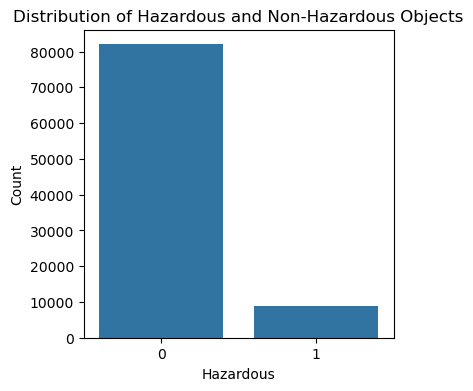

In [26]:
plt.figure(figsize=(4,4))
sns.countplot(x=df["hazardous"])
plt.title("Distribution of Hazardous and Non-Hazardous Objects")
plt.xlabel("Hazardous")
plt.ylabel("Count")
plt.show()

## Correlation Heatmap

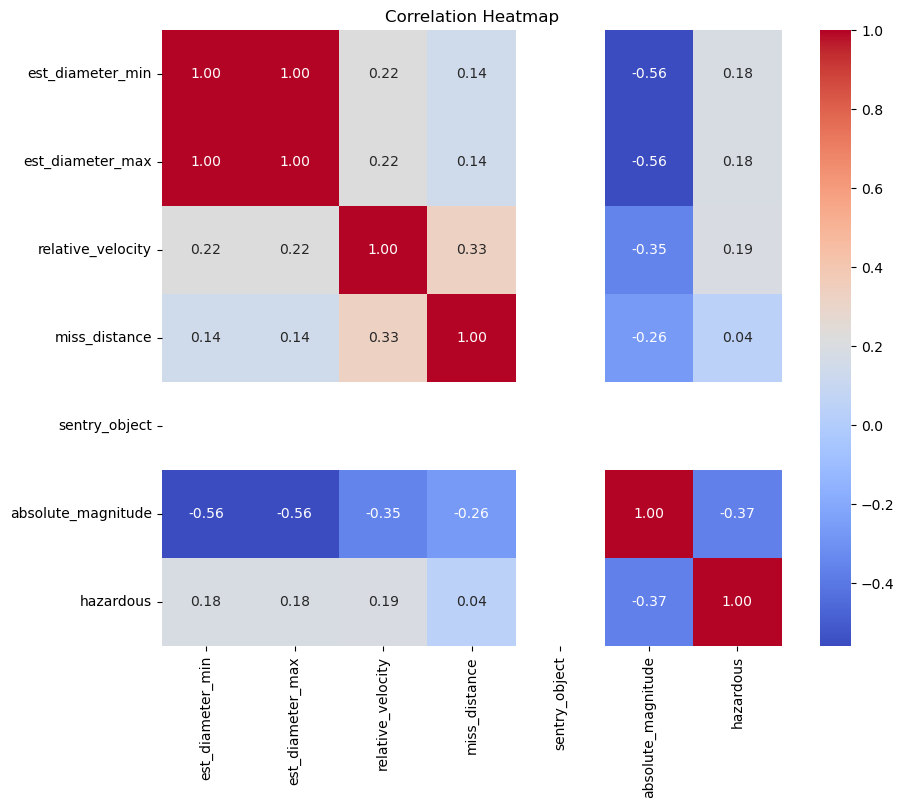

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Distribution of Numerical Features

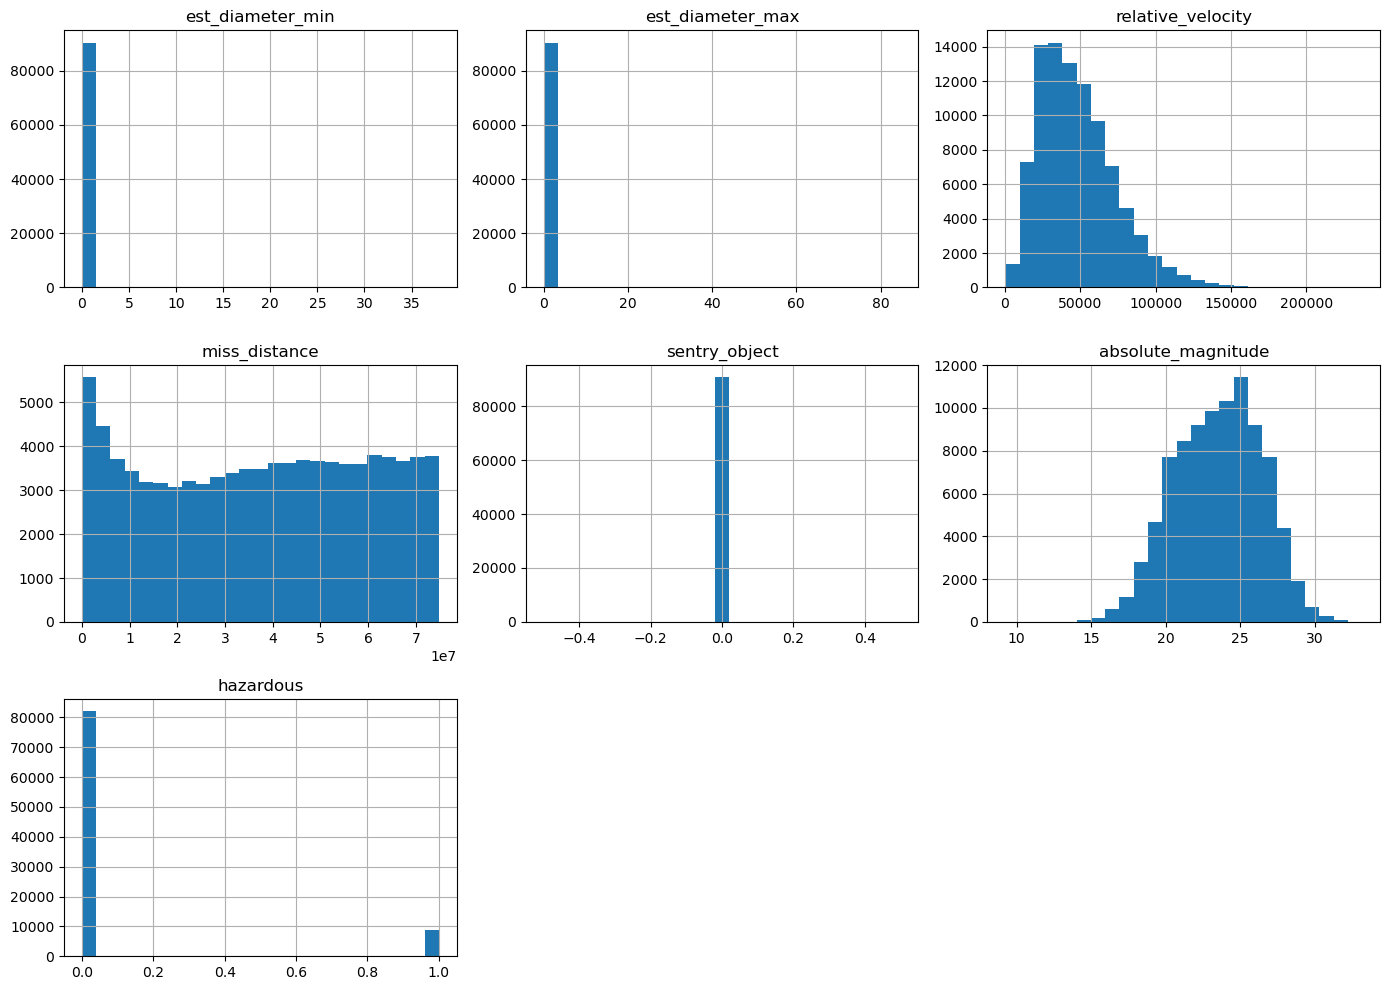

In [28]:
df.hist(figsize=(14,10),bins=25)
plt.tight_layout()
plt.show()

## Outliers Detection

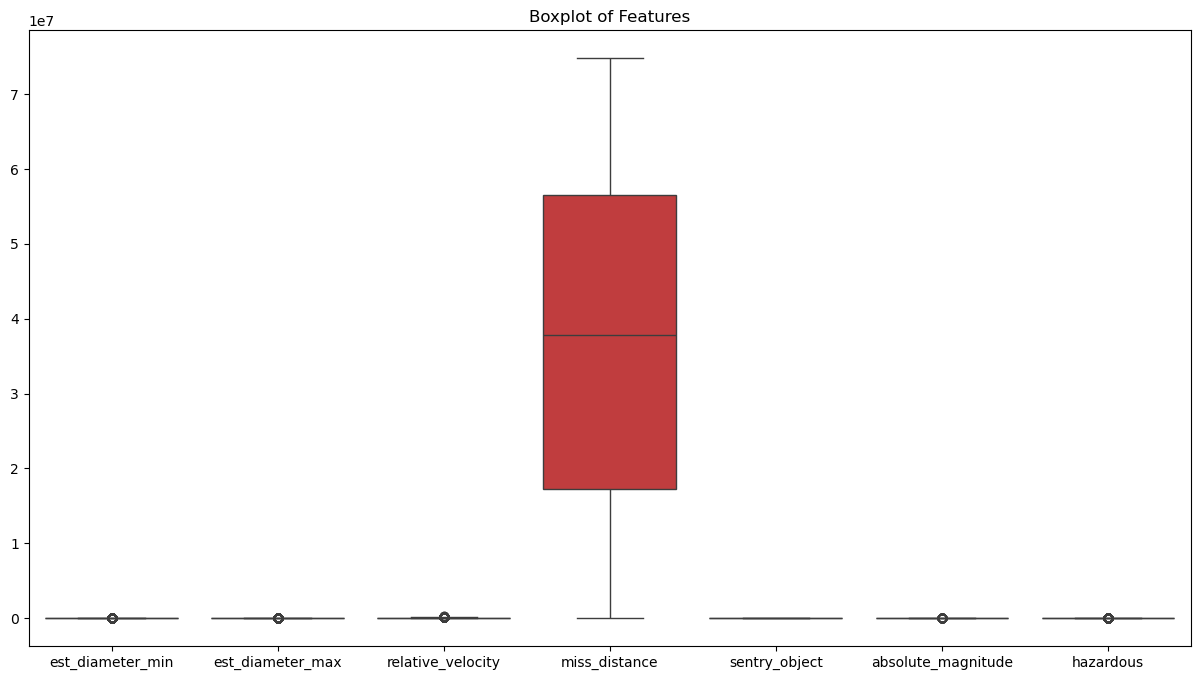

In [29]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.show()

## Hazardous vs Relative Velocity

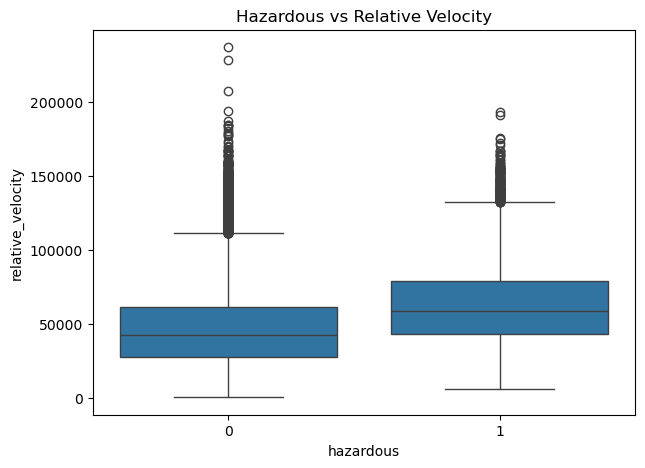

In [30]:
plt.figure(figsize=(7,5))
sns.boxplot(x="hazardous",y="relative_velocity",data=df)
plt.title("Hazardous vs Relative Velocity")
plt.show()

## Hazardous vs Miss Distance

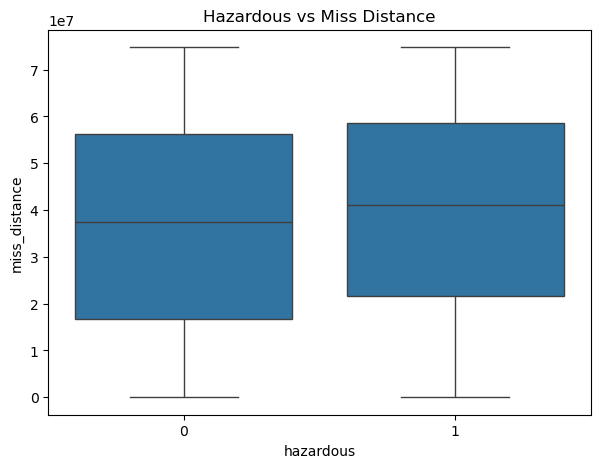

In [31]:
plt.figure(figsize=(7,5))
sns.boxplot(x="hazardous",y="miss_distance",data=df)
plt.title("Hazardous vs Miss Distance")
plt.show()

## Hazardous vs Absolute Magnitude 

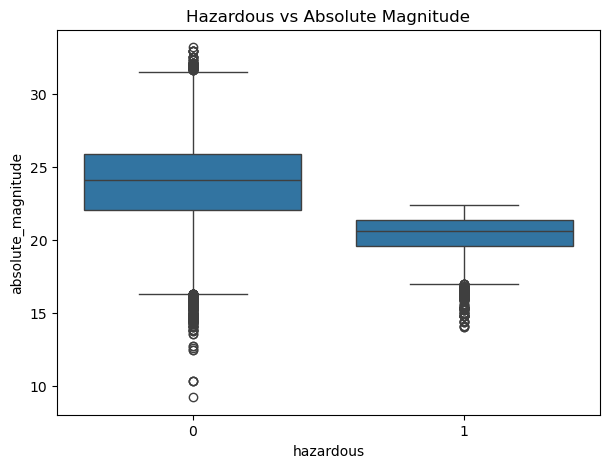

In [32]:
plt.figure(figsize=(7,5))
sns.boxplot(x="hazardous",y="absolute_magnitude",data=df)
plt.title("Hazardous vs Absolute Magnitude")
plt.show()

## Pairplot

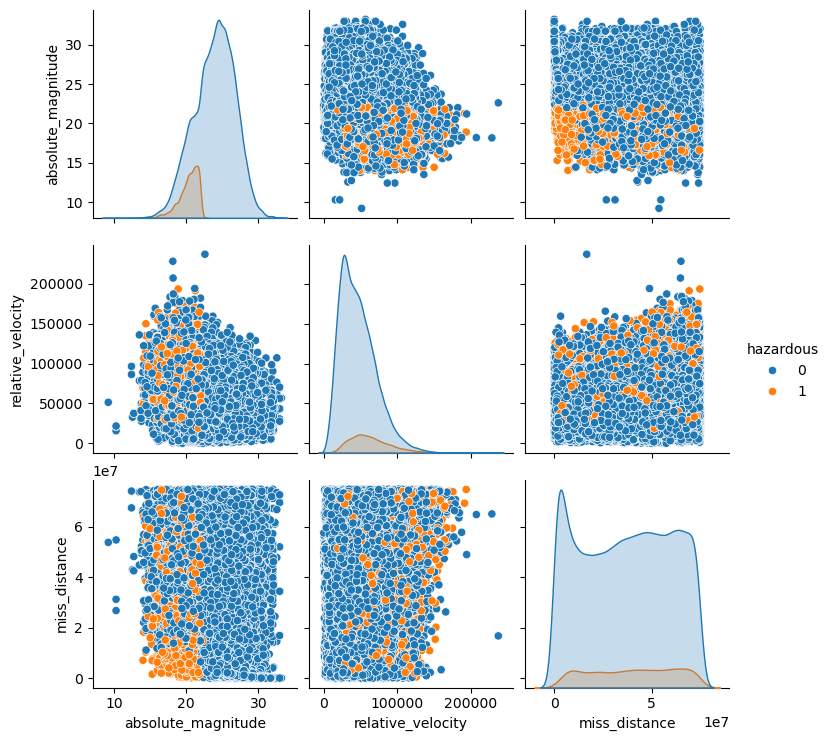

In [33]:
sns.pairplot(df[["absolute_magnitude","relative_velocity","miss_distance","hazardous"]],hue="hazardous")
plt.show()

## Correlation with Target

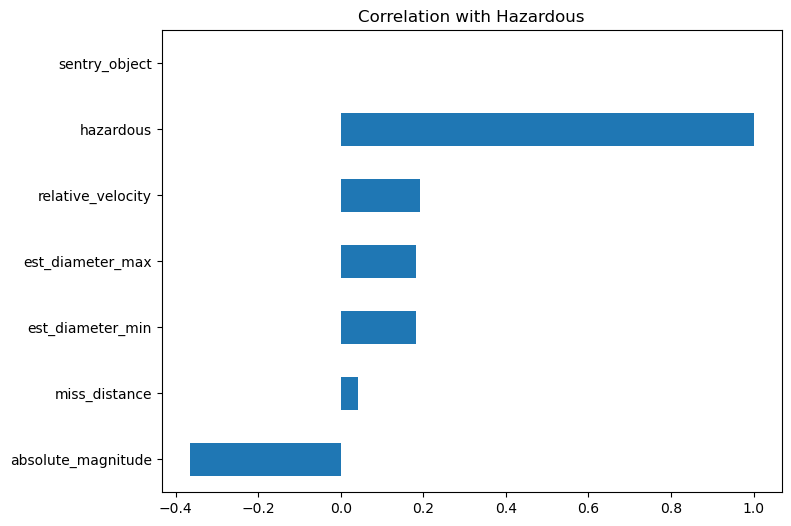

In [34]:
plt.figure(figsize=(8,6))
df.corr()["hazardous"].sort_values().plot(kind="barh")
plt.title("Correlation with Hazardous")
plt.show()

## Overall EDA Summary

1. The dataset is highly imbalanced, with significantly more non-hazardous objects than hazardous ones. This imbalance should be considered during model evaluation.
2. Estimated minimum diameter and estimated maximum diameter are perfectly correlated, indicating that they represent the same physical characteristic and contain redundant information.
3. Relative velocity shows a weak positive correlation with the hazardous label, and hazardous objects generally exhibit higher velocities, making it an important predictive feature.
4. Absolute magnitude has a moderate negative correlation with the hazardous label. Hazardous asteroids generally have lower absolute magnitude values, indicating they are brighter and potentially larger.
5. Miss distance has very little direct correlation with hazard status. Its distribution is similar for both classes, suggesting it should be used together with other features rather than alone.
6. The numerical features have different distributions. Relative velocity is positively skewed, absolute magnitude is approximately bell-shaped, and miss distance spans a wide range of values.
7. Several numerical features contain astronomical outliers, especially relative velocity and miss distance. These represent real observations rather than data errors and should generally be retained.
8. The pairplot shows that no single feature can perfectly separate hazardous and non-hazardous objects. Instead, the classes overlap considerably, indicating that multiple features must be combined for accurate classification.
9. The correlation with the target plot confirms that absolute magnitude has the strongest negative relationship with the target, while relative velocity and estimated diameter show positive relationships. Miss distance contributes relatively little on its own.
10. Overall, the exploratory analysis indicates that hazard prediction depends on the combination of several physical and orbital characteristics rather than a single variable, making this a suitable supervised machine learning classification problem.

# Model Development

## Importing the Required libraries

In [35]:
!pip install xgboost

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

## Training Logistic Regression Model

In [37]:
lr=LogisticRegression(random_state=37)
lr.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",37
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [38]:
# Predicting the Test set
y_pred_lr=lr.predict(X_test)
y_pred_lr

array([0, 0, 0, ..., 0, 0, 0], shape=(18168,))

In [39]:
# Accuracy of the model
accuracy_lr=accuracy_score(y_test,y_pred_lr)
print("Accuracy:",accuracy_lr)

Accuracy: 0.9009797446059005


In [40]:
# Precision
precision_lr=precision_score(y_test,y_pred_lr)
print("Precision:",precision_lr)

Precision: 0.4478114478114478


In [41]:
# Recall
recall_lr=recall_score(y_test,y_pred_lr)
print("Recall:",recall_lr)

Recall: 0.0752262443438914


In [42]:
# F1 Score
f1_lr=f1_score(y_test,y_pred_lr)
print("F1 Score:",f1_lr)

F1 Score: 0.1288135593220339


In [43]:
# Classification Report
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     16400
           1       0.45      0.08      0.13      1768

    accuracy                           0.90     18168
   macro avg       0.68      0.53      0.54     18168
weighted avg       0.86      0.90      0.87     18168



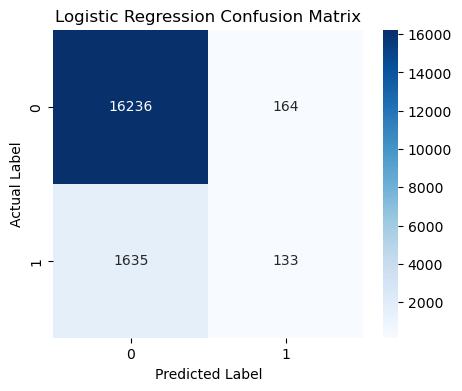

In [44]:
# Confusion Matrix
cm_lr=confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Training Decision Tree Model

In [45]:
dt=DecisionTreeClassifier(random_state=37)
dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",37
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [46]:
# Predicting the Test set
y_pred_dt=dt.predict(X_test)
y_pred_dt

array([1, 0, 0, ..., 0, 0, 0], shape=(18168,))

In [47]:
# Accuracy of the model
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Accuracy:",accuracy_dt)

Accuracy: 0.8944297666226332


In [48]:
# Precision
precision_dt=precision_score(y_test,y_pred_dt)
print("Precision:",precision_dt)

Precision: 0.45865490628445427


In [49]:
# Recall
recall_dt=recall_score(y_test,y_pred_dt)
print("Recall:",recall_dt)

Recall: 0.47058823529411764


In [50]:
# F1 Score
f1_dt=f1_score(y_test,y_pred_dt)
print("F1 Score:",f1_dt)

F1 Score: 0.46454494695700727


In [51]:
# Classification Report
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94     16400
           1       0.46      0.47      0.46      1768

    accuracy                           0.89     18168
   macro avg       0.70      0.71      0.70     18168
weighted avg       0.90      0.89      0.90     18168



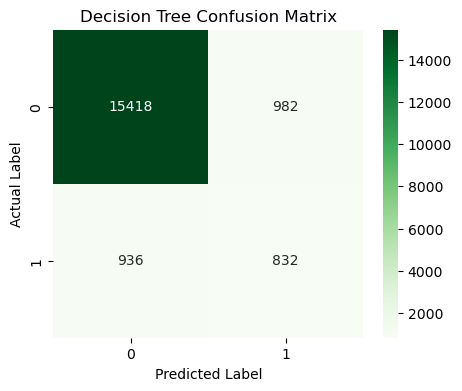

In [52]:
# Confusion Matrix
cm_dt=confusion_matrix(y_test,y_pred_dt)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt,annot=True,fmt="d",cmap="Greens")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Training Random Forest Model

In [53]:
rf=RandomForestClassifier(n_estimators=200,random_state=37)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",37
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [54]:
# Predicting the Test set
y_pred_rf=rf.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 1, 0], shape=(18168,))

In [55]:
# Accuracy of the model
accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("Accuracy:",accuracy_rf)

Accuracy: 0.9162263320123294


In [56]:
# Precision
precision_rf=precision_score(y_test,y_pred_rf)
print("Precision:",precision_rf)

Precision: 0.6008196721311475


In [57]:
# Recall
recall_rf=recall_score(y_test,y_pred_rf)
print("Recall:",recall_rf)

Recall: 0.4145927601809955


In [58]:
# F1 Score
f1_rf=f1_score(y_test,y_pred_rf)
print("F1 Score:",f1_rf)

F1 Score: 0.49062918340026773


In [59]:
# Classification Report
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     16400
           1       0.60      0.41      0.49      1768

    accuracy                           0.92     18168
   macro avg       0.77      0.69      0.72     18168
weighted avg       0.91      0.92      0.91     18168



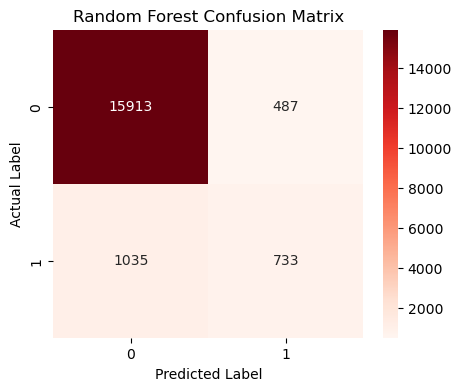

In [60]:
# Confusion Matrix
cm_rf=confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Reds")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Training Gradient Boosting Model

In [61]:
gb = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=37)
gb.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",37
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [62]:
# Predicting the Test set
y_pred_gb=gb.predict(X_test)
y_pred_gb

array([0, 0, 0, ..., 0, 0, 0], shape=(18168,))

In [63]:
# Accuracy of the model
accuracy_gb=accuracy_score(y_test,y_pred_gb)
print("Accuracy:",accuracy_gb)

Accuracy: 0.9132540730955526


In [64]:
# Precision
precision_gb=precision_score(y_test,y_pred_gb)
print("Precision:",precision_gb)

Precision: 0.7840236686390533


In [65]:
# Recall
recall_gb=recall_score(y_test,y_pred_gb)
print("Recall:",recall_gb)

Recall: 0.1498868778280543


In [66]:
# F1 Score
f1_gb=f1_score(y_test,y_pred_gb)
print("F1 Score:",f1_gb)

F1 Score: 0.251661918328585


In [67]:
# Classification Report
print(classification_report(y_test,y_pred_gb))

              precision    recall  f1-score   support

           0       0.92      1.00      0.95     16400
           1       0.78      0.15      0.25      1768

    accuracy                           0.91     18168
   macro avg       0.85      0.57      0.60     18168
weighted avg       0.90      0.91      0.89     18168



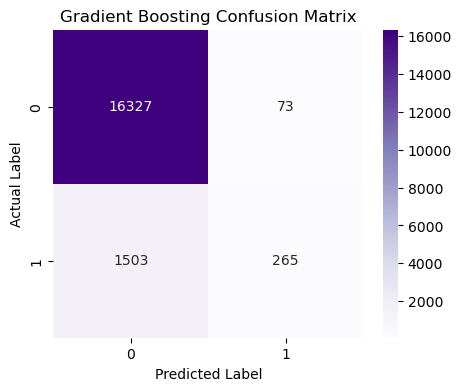

In [68]:
# Confusion Matrix
cm_gb=confusion_matrix(y_test,y_pred_gb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gb,annot=True,fmt="d",cmap="Purples")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

## Training the XGBoost Model

In [69]:
xgb = XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=5,random_state=37,use_label_encoder=False,eval_metric="logloss")
xgb.fit(X_train, y_train)

D:\AnacondaDistribution\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:45:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [70]:
# Predicting the Test set
y_pred_xgb=xgb.predict(X_test)
y_pred_xgb

array([0, 0, 0, ..., 0, 0, 0], shape=(18168,))

In [71]:
# Accuracy of the model
accuracy_xgb=accuracy_score(y_test,y_pred_xgb)
print("Accuracy:",accuracy_xgb)

Accuracy: 0.9163364156759137


In [72]:
# Precision
precision_xgb=precision_score(y_test,y_pred_xgb)
print("Precision:",precision_xgb)

Precision: 0.7627118644067796


In [73]:
# Recall
recall_xgb=recall_score(y_test,y_pred_xgb)
print("Recall:",recall_xgb)

Recall: 0.20361990950226244


In [74]:
# F1 Score
f1_xgb=f1_score(y_test,y_pred_xgb)
print("F1 Score:",f1_xgb)

F1 Score: 0.32142857142857145


In [75]:
# Classification Report
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     16400
           1       0.76      0.20      0.32      1768

    accuracy                           0.92     18168
   macro avg       0.84      0.60      0.64     18168
weighted avg       0.91      0.92      0.89     18168



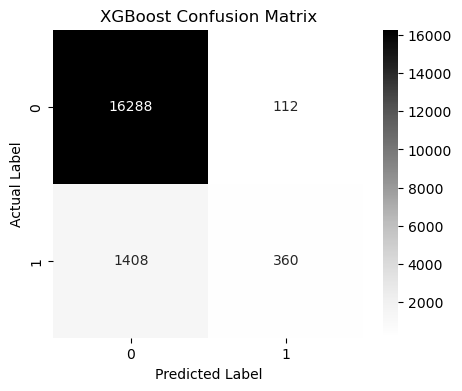

In [76]:
# Confusion Matrix
cm_xgb=confusion_matrix(y_test,y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb,annot=True,fmt="d",cmap="Greys")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.show()

# Model Optimization and Comparison

## Comparing the Models

In [77]:
results=pd.DataFrame({"Model":["Logistic Regression","Decision Tree","Random Forest","Gradient Boosting","XGBoost"],
                        "Accuracy":[accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_dt),accuracy_score(y_test,y_pred_rf),accuracy_score(y_test,y_pred_gb),accuracy_score(y_test,y_pred_xgb)],
                        "Precision":[precision_score(y_test,y_pred_lr),precision_score(y_test,y_pred_dt),precision_score(y_test,y_pred_rf),precision_score(y_test,y_pred_gb),precision_score(y_test,y_pred_xgb)],
                        "Recall":[recall_score(y_test,y_pred_lr),recall_score(y_test,y_pred_dt),recall_score(y_test,y_pred_rf),recall_score(y_test,y_pred_gb),recall_score(y_test,y_pred_xgb)],
                        "F1 Score":[f1_score(y_test,y_pred_lr),f1_score(y_test,y_pred_dt),f1_score(y_test,y_pred_rf),f1_score(y_test,y_pred_gb),f1_score(y_test,y_pred_xgb)]})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.900980,0.447811,0.075226,0.128814
1,Decision Tree,0.894430,0.458655,0.470588,0.464545
2,Random Forest,0.916226,0.600820,0.414593,0.490629
3,Gradient Boosting,0.913254,0.784024,0.149887,0.251662
4,XGBoost,0.916336,0.762712,0.203620,0.321429


In [78]:
# Best Model
results.sort_values(by="F1 Score",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.916226,0.600820,0.414593,0.490629
1,Decision Tree,0.894430,0.458655,0.470588,0.464545
4,XGBoost,0.916336,0.762712,0.203620,0.321429
3,Gradient Boosting,0.913254,0.784024,0.149887,0.251662
0,Logistic Regression,0.900980,0.447811,0.075226,0.128814


C:\Users\Divyanshi Kesharwani\AppData\Local\Temp\ipykernel_37328\318835659.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results,x="Model",y="Accuracy",palette="viridis")


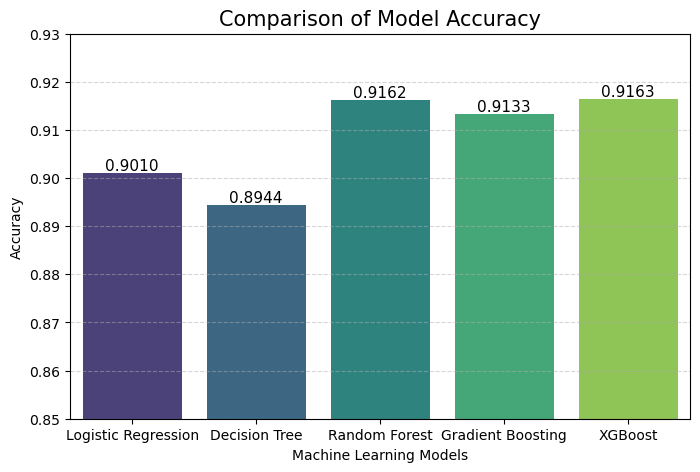

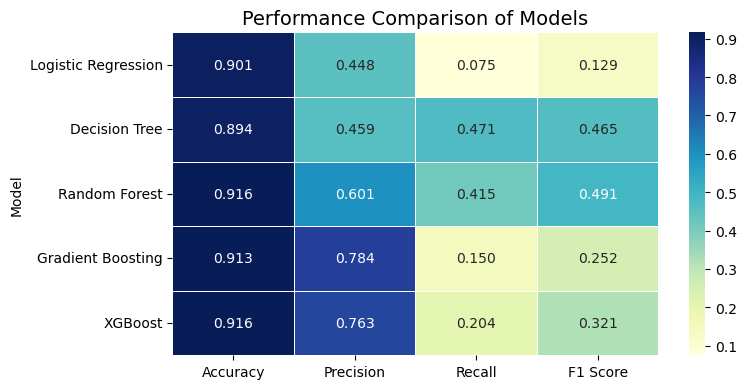

In [79]:
# Visual Comparison of Best Model
plt.figure(figsize=(8,5))
ax = sns.barplot(data=results,x="Model",y="Accuracy",palette="viridis")
for i in ax.containers:
    ax.bar_label(i, fmt="%.4f",fontsize=11)
plt.title("Comparison of Model Accuracy",fontsize=15)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.ylim(0.85,0.93)
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

plt.figure(figsize=(8,4))
sns.heatmap(results.set_index("Model"),annot=True,fmt=".3f",cmap="YlGnBu",linewidths=0.5,linecolor="white")
plt.title("Performance Comparison of Models", fontsize=14)
plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)

In [80]:
importance=pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})
importance=importance.sort_values(by="Importance",ascending=False)
importance

,Feature,Importance
3,miss_distance,0.299550
2,relative_velocity,0.265862
0,est_diameter_min,0.151078
5,absolute_magnitude,0.147933
1,est_diameter_max,0.135576
4,sentry_object,0.000000


C:\Users\Divyanshi Kesharwani\AppData\Local\Temp\ipykernel_37328\3851503863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance,x="Importance",y="Feature",palette="rocket")


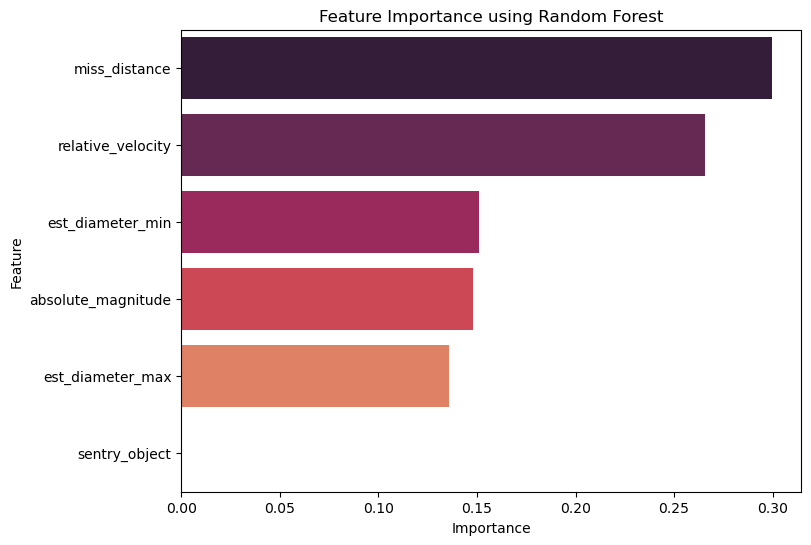

In [81]:
plt.figure(figsize=(8,6))
sns.barplot(data=importance,x="Importance",y="Feature",palette="rocket")
plt.title("Feature Importance using Random Forest")
plt.show()

# Hyperparameter Tuning

In [82]:
from sklearn.model_selection import GridSearchCV
# Parameter Grid
params={"n_estimators":[100,200,300],"max_depth":[10,20,None],"min_samples_split":[2,5],"min_samples_leaf":[1,2]}

In [83]:
# Grid Search
grid=GridSearchCV(RandomForestClassifier(random_state=37),param_grid=params,cv=5,scoring="f1",n_jobs=-1)
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=37)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [84]:
# Best Parameters
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [85]:
# Best Cross Validation Score
print("Best Cross Validation Score:")
print(grid.best_score_)

Best Cross Validation Score:
0.49497647689454316


In [86]:
# Training Optimized Model
best_rf=grid.best_estimator_
best_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",37
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [87]:
# Prdection of Test set
y_pred_best=best_rf.predict(X_test)
y_pred_best

array([0, 0, 0, ..., 0, 1, 0], shape=(18168,))

In [88]:
# Final Evaluation
accuracy_best=accuracy_score(y_test,y_pred_best)
precision_best=precision_score(y_test,y_pred_best)
recall_best=recall_score(y_test,y_pred_best)
f1_best=f1_score(y_test, y_pred_best)
print("Accuracy :",accuracy_best)
print("Precision:",precision_best)
print("Recall   :",recall_best)
print("F1 Score :",f1_best)

Accuracy : 0.915785997357992
Precision: 0.5975409836065574
Recall   : 0.4123303167420814
F1 Score : 0.4879518072289157


In [89]:
# Classifiaction Report
print(classification_report(y_test,y_pred_best))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     16400
           1       0.60      0.41      0.49      1768

    accuracy                           0.92     18168
   macro avg       0.77      0.69      0.72     18168
weighted avg       0.91      0.92      0.91     18168



In [90]:
# Performance Comparison
comparison=pd.DataFrame({"Metric":["Accuracy", "Precision", "Recall", "F1 Score"],
                           "Default Random Forest":[accuracy_rf,precision_rf,recall_rf,f1_rf],
                           "Tuned Random Forest":[accuracy_best,precision_best,recall_best,f1_best]})
comparison

,Metric,Default Random Forest,Tuned Random Forest
0,Accuracy,0.916226,0.915786
1,Precision,0.600820,0.597541
2,Recall,0.414593,0.412330
3,F1 Score,0.490629,0.487952


Since the Default Random Forest Model outperformed the Tuned Random Forest Model so I am choosing the default one only.

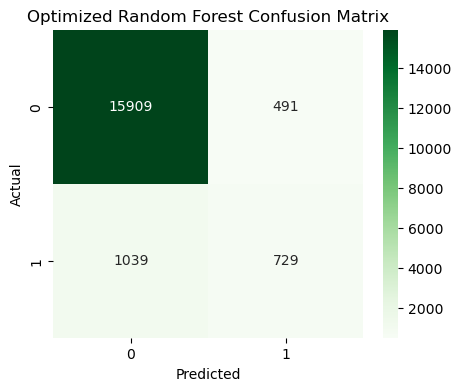

In [92]:
# Confusion Matrix
cm=confusion_matrix(y_test,y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized Random Forest Confusion Matrix")
plt.show()

# Best Model selection

In [93]:
# Saving the final model
import joblib
joblib.dump(rf,"best_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [96]:
# Loading the saved files 
loaded_model=joblib.load("best_model.pkl")
loaded_scaler=joblib.load("scaler.pkl")
print("Model Loaded Successfully!")

Model Loaded Successfully!


In [97]:
# Verifying the saved model
loaded_prediction=loaded_model.predict(X_test)
print("Accuracy of Loaded Model:",accuracy_score(y_test,loaded_prediction))

Accuracy of Loaded Model: 0.9162263320123294


In [98]:
# Saving Feature names
feature_names=X.columns.tolist()
joblib.dump(feature_names,"feature_names.pkl")
print(feature_names)

['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'sentry_object', 'absolute_magnitude']


In [99]:
# Verifying Feature names
loaded_features=joblib.load("feature_names.pkl")
print("Saved Features:")
print(loaded_features)

Saved Features:
['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'sentry_object', 'absolute_magnitude']


In [100]:
# Checking saved files
import os
print("Current Directory:")
print(os.getcwd())
print("\nSaved Files:")
for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

Current Directory:
D:\ML Internship\NASA-NEO-Predictor\Notebook

Saved Files:
best_model.pkl
feature_names.pkl
scaler.pkl


1. The Random Forest classifier was selected as the final model based on its superior performance.
2. The trained model was serialized using the Joblib library.
3. The feature scaler was also saved to ensure consistent preprocessing during inference.
4. Feature names were stored to maintain the correct input order during prediction.
5. These saved files will be used in the Streamlit web application for real-time hazardous asteroid prediction.